# Decision Tree Regressor

## Taxi trip price prediction

In [1]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

In [2]:
# loading the dataset
df = pd.read_csv("/content/taxi_trip_pricing (1).csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


## Data Cleaning

In [3]:
# Checking for nan values
df[df.isnull()]

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# handling nan values
df.dropna(inplace=True)

In [5]:
# dropping duplicate rows
df.drop_duplicates(inplace=True)
df.shape

(562, 11)

## EDA

In [6]:
# Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,2,0,3.0,1,0,3.56,0.80,0.32,53.82,36.2624
2,36.87,1,1,1.0,0,0,2.70,1.21,0.15,37.27,52.9032
5,8.64,0,1,2.0,2,0,2.55,1.71,0.48,89.33,60.2028
12,41.79,3,1,3.0,0,0,4.60,1.77,0.11,86.95,88.1328
14,9.91,1,0,2.0,0,0,2.32,1.26,0.34,41.72,28.9914


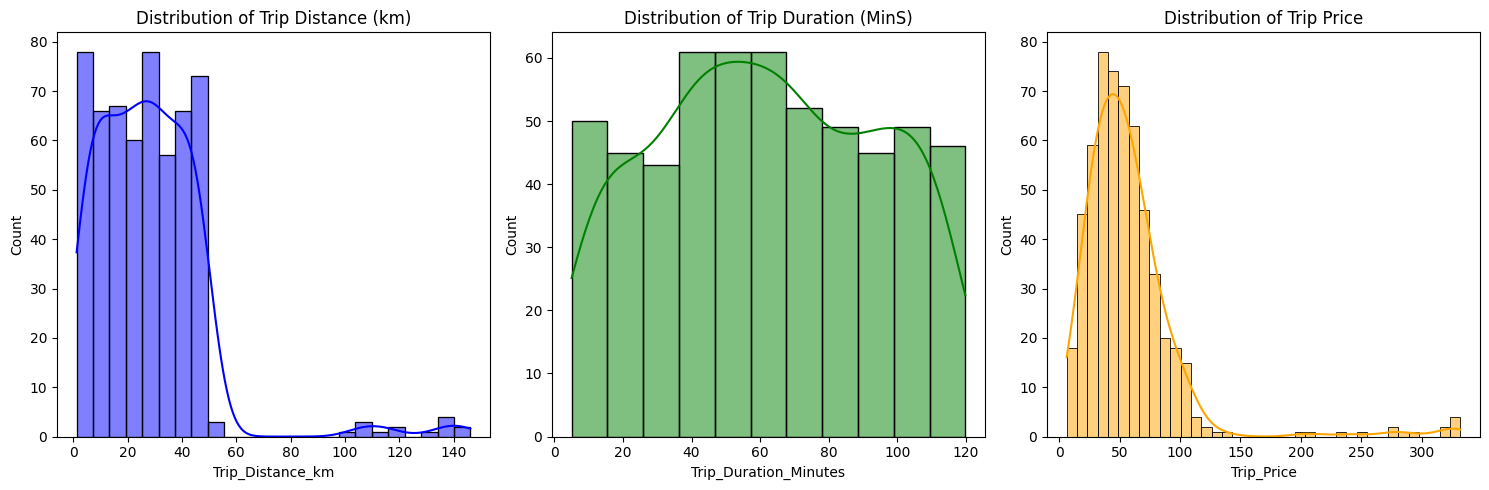

In [7]:
# Create subplots
fig, axes = plt.subplots(1,3,figsize=(15, 5))
# Trip Distance
sns.histplot(x="Trip_Distance_km",data=df,kde=True,ax=axes[0],color="blue")
axes[0].set_title("Distribution of Trip Distance (km)")
# Trip Duration
sns.histplot(x="Trip_Duration_Minutes",data=df,kde=True,ax=axes[1],color="green")
axes[1].set_title("Distribution of Trip Duration (MinS)")
# Trip Price
sns.histplot(x="Trip_Price",data=df,kde=True,ax=axes[2],color="orange")
axes[2].set_title("Distribution of Trip Price")

plt.tight_layout()
plt.show()


<Axes: >

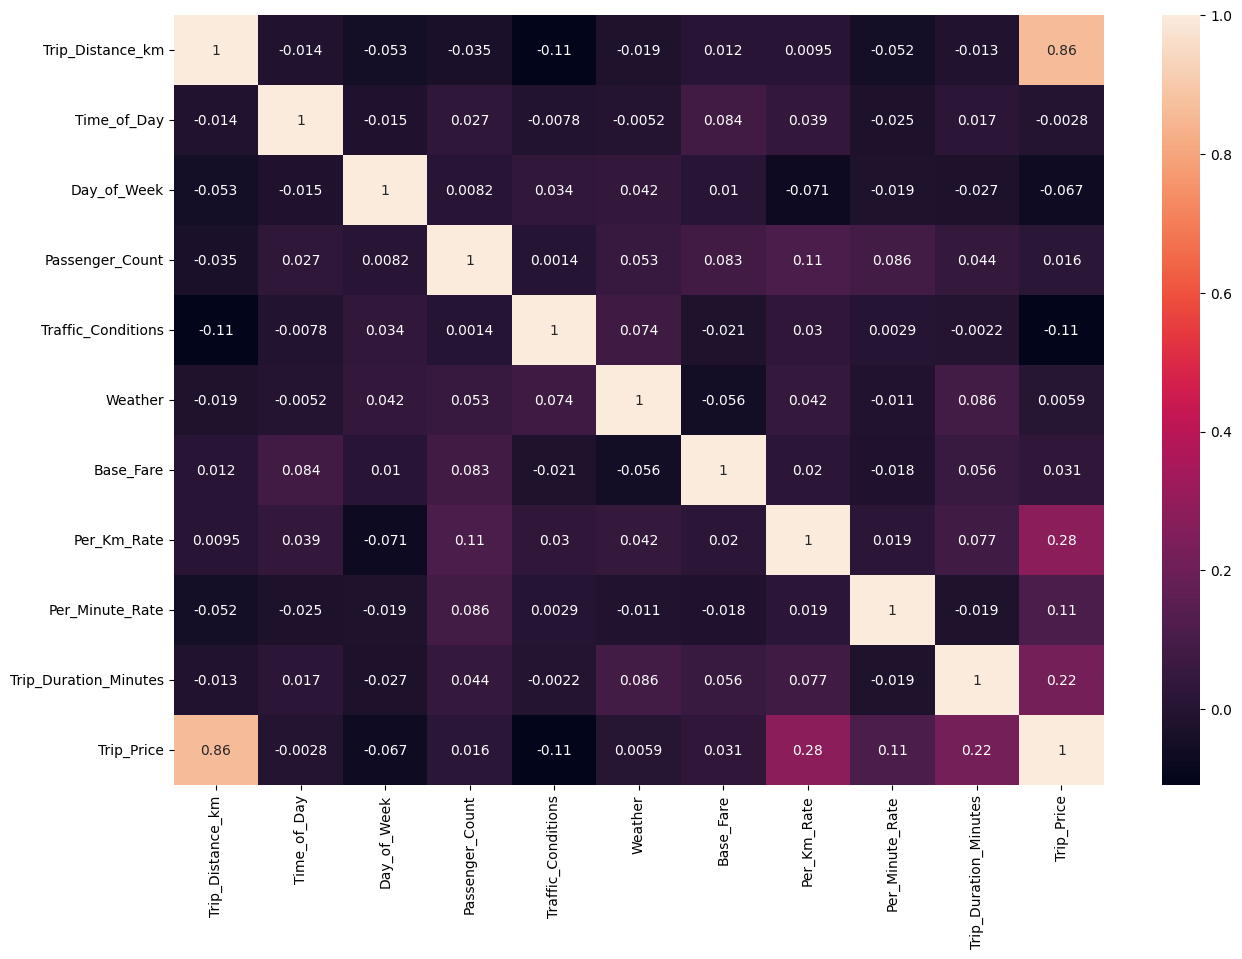

In [8]:
#  Getting Correlation between columns
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),annot=True)

## Model Training

In [9]:
# Dividing data into input and output
X = df.drop("Trip_Price",axis=1)
y = df["Trip_Price"]

In [10]:
# Splitting data for training and testing
Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,test_size=0.3,random_state=42)

In [11]:
# Scaling for better efficiency
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
Xtrain = sc.fit_transform(Xtrain)
Xtest = sc.transform(Xtest)

In [14]:
# model training
model = DecisionTreeRegressor(max_depth=5)
model.fit(Xtrain,ytrain)

DecisionTreeRegressor(max_depth=5)

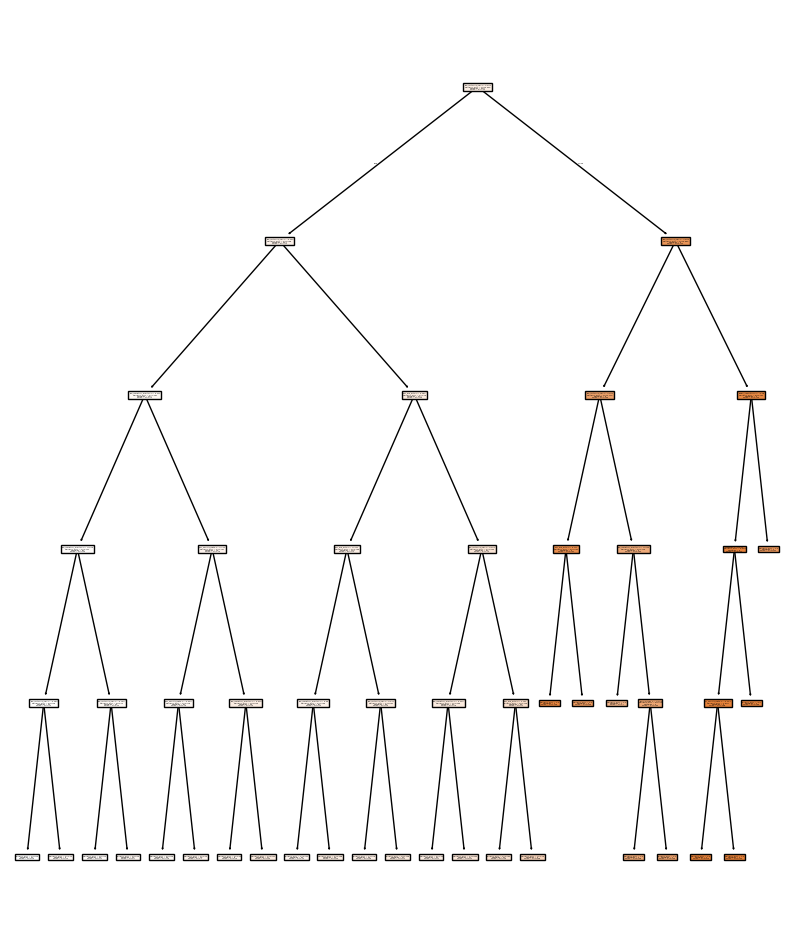

In [15]:
# Plotting decision tree
from sklearn.tree import plot_tree
plt.figure(figsize=(10,12))
plot_tree(model,feature_names=df.columns[:-1],filled=True)
plt.show()

In [16]:
# Prediction
ypred = model.predict(Xtest)
ypred

array([ 43.14085273,  62.989236  ,  39.66001875,  43.14085273,
        46.51005   ,  28.47706786,  70.2208814 ,  43.14085273,
        43.14085273,  62.989236  ,  16.87452778,  34.32392222,
        46.51005   ,  62.15707727,  16.87452778,  96.49908485,
        96.49908485,  67.03638824,  43.14085273,  46.51005   ,
        35.40906   ,  39.66001875,  70.2208814 ,  43.14085273,
        43.14085273,  70.2208814 ,  35.40906   ,  56.988364  ,
        16.87452778,  62.989236  ,  46.51005   ,  43.14085273,
        62.15707727,  43.14085273,  79.59052727,  79.59052727,
        79.59052727,  34.32392222, 274.5350868 ,  16.87452778,
        46.51005   ,  67.03638824,  96.49908485, 126.86753333,
        34.32392222,  67.03638824,  35.40906   ,  39.66001875,
        62.989236  ,  39.66001875,  79.59052727,  67.03638824,
        39.66001875,  28.47706786,  39.66001875,  96.49908485,
        43.14085273,  39.66001875,  56.988364  ,  79.59052727,
        46.51005   ,  56.988364  ,  39.66001875,  35.40

In [17]:
# Efficiency
print("Training Eff: ",model.score(Xtrain,ytrain))
print("Testing Eff: ",model.score(Xtest,ytest))

Training Eff:  0.9481923034098073
Testing Eff:  0.907951535997782


In [18]:
# Performance metrics
print("R2: ",r2_score(ytest,ypred))
print("MAE: ",mean_absolute_error(ytest,ypred))
print("MSE: ",mean_squared_error(ytest,ypred))

R2:  0.907951535997782
MAE:  10.71057925527922
MSE:  200.02790582566962
